# Sample Latest Artificial NodeField Generator

Loads the most recently modified saved artificial NodeField generator and runs sampling only.

In [21]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

from IPython.display import HTML
import logging
import os
import warnings

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_SILENT'] = 'true'
warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")
warnings.filterwarnings('ignore', message=r'.*pkg_resources is deprecated as an API.*')
warnings.filterwarnings('ignore', message=r'.*Initializing zero-element tensors is a no-op.*')
warnings.filterwarnings('ignore', message=r".*does not have many workers.*")
warnings.filterwarnings('ignore', message=r'.*CrossEntropyMetric was called before the ``update`` method.*')
try:
    from pytorch_lightning.utilities.warnings import PossibleUserWarning
    warnings.filterwarnings('ignore', category=PossibleUserWarning)
except Exception:
    pass
for logger_name in ('pytorch_lightning', 'lightning', 'wandb'):
    logging.getLogger(logger_name).setLevel(logging.ERROR)

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo.artificial import (
    artificial_feasibility_titles,
    artificial_part_estimator_summary,
    artificial_true_count_histogram,
    assert_artificial_part_feasibility,
    build_artificial_plotter,
    compare_artificial_feasibility_efforts,
    draw_artificial_graphs,
    find_latest_artificial_dataset_config,
    fit_artificial_part_feasibility_estimators,
    load_artificial_feasibility_graphs,
    load_latest_artificial_graph_generator,
    score_artificial_part_feasibility,
    summarize_graphs,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch version: 2.2.2
CUDA available: False


In [22]:
N_SAMPLES = 1
N_COLS = 7
NODE_ALPHABET_SIZE = 3
NODE_ALPHABET_KIND = 'int'
COMPONENT_SPECIFIC_ALPHABETS = True

FEASIBILITY_EFFORT = 1
FEASIBILITY_FILTER = 'none'  # 'none', 'fallback', or 'strict'

MODEL_DIR = SAVED_GENERATOR_ROOT
MODEL_PATTERNS = ('artificial*.pkl', '*artificial*.pkl')

TRUE_FEASIBILITY_N_GRAPHS = 100
FEASIBILITY_ESTIMATOR_N_JOBS = 8


In [23]:
graph_generator, generator_model_path = load_latest_artificial_graph_generator(
    MODEL_DIR,
    patterns=MODEL_PATTERNS,
)
plot_artificial_graphs = build_artificial_plotter(
    node_alphabet_size=NODE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
)
draw_graphs = lambda graphs, **kwargs: draw_artificial_graphs(
    graphs,
    plotter=plot_artificial_graphs,
    **kwargs,
)

print(f'Loaded latest artificial generator: {generator_model_path}')
print('model_name =', getattr(graph_generator, 'model_name', None))
print('is_fitted_ =', getattr(graph_generator, 'is_fitted_', None))
print('cached training conditioning =', len(getattr(graph_generator, 'training_graph_conditioning_', []) or []))


Loaded graph generator: artificial-cycle-path-star-n10000-c-3-8-p2-r3x1-d128-b128-e350.pkl
/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/saved_generators/artificial-cycle-path-star-n10000-c-3-8-p2-r3x1-d128-b128-e350.pkl
Loaded latest artificial generator: /Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/saved_generators/artificial-cycle-path-star-n10000-c-3-8-p2-r3x1-d128-b128-e350.pkl
model_name = artificial-cycle-path-star-n10000-c-3-8-p2-r3x1-d128-b128-e350
is_fitted_ = True
cached training conditioning = 10000


In [24]:
ARTIFICIAL_DATASET_CONFIG_PATH = find_latest_artificial_dataset_config(REPO_ROOT / 'notebooks')
true_feasibility_graphs = load_artificial_feasibility_graphs(
    ARTIFICIAL_DATASET_CONFIG_PATH,
    n_graphs=TRUE_FEASIBILITY_N_GRAPHS,
)

print(f'Using true artificial dataset config: {ARTIFICIAL_DATASET_CONFIG_PATH}')
print(f'Generated {len(true_feasibility_graphs)} true graphs to fit and test decomposed feasibility.')


Using true artificial dataset config: /Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/notebooks/artificial-cycle-path-star-n10000-c3-8-p2-r3x1-na3.yaml
Generated 100 true graphs to fit and test decomposed feasibility.


In [25]:
artificial_part_feasibility_estimators, artificial_part_labels = fit_artificial_part_feasibility_estimators(
    true_feasibility_graphs,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
    n_jobs=FEASIBILITY_ESTIMATOR_N_JOBS,
)
display(artificial_part_estimator_summary(artificial_part_feasibility_estimators, artificial_part_labels))

true_part_feasibility = assert_artificial_part_feasibility(
    artificial_part_feasibility_estimators,
    true_feasibility_graphs,
)
print(f'True-graph feasibility smoke test passed: {len(true_feasibility_graphs)}/{len(true_feasibility_graphs)}')


,part,labels,seen_features
0,cycle,"[0, 1, 2]",76
1,path,"[3, 4, 5]",8
2,branching,"[6, 7, 8]",30


True-graph feasibility smoke test passed: 100/100


In [ ]:
N_SAMPLES = 30
FEASIBILITY_EFFORT = 5
FEASIBILITY_FILTER = 'none' # 'none', 'fallback', or 'strict'

filtered_samples = graph_generator.sample(
    n_samples=N_SAMPLES,
    feasibility_effort=FEASIBILITY_EFFORT,
    feasibility_filter=FEASIBILITY_FILTER,
)

_ = draw_graphs(
    filtered_samples,
    n=len(filtered_samples),
    title=f'Generation samples | effort={FEASIBILITY_EFFORT}, filter={FEASIBILITY_FILTER}',
    n_graphs_per_line=min(7, N_SAMPLES),
)

Exception ignored in: <function _releaseLock at 0x10e2cafc0>
Traceback (most recent call last):
  File "/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/logging/__init__.py", line 237, in _releaseLock
    def _releaseLock():
    
KeyboardInterrupt: 


Feasible generated graphs: 2/20


,cycle,path,branching,count
0,False,False,False,3
1,False,False,True,3
2,False,True,False,3
3,False,True,True,7
4,True,False,False,1
5,True,True,False,1
6,True,True,True,2


,n_true,count,fraction
0,3,2,0.10
1,2,8,0.40
2,1,7,0.35
3,0,3,0.15


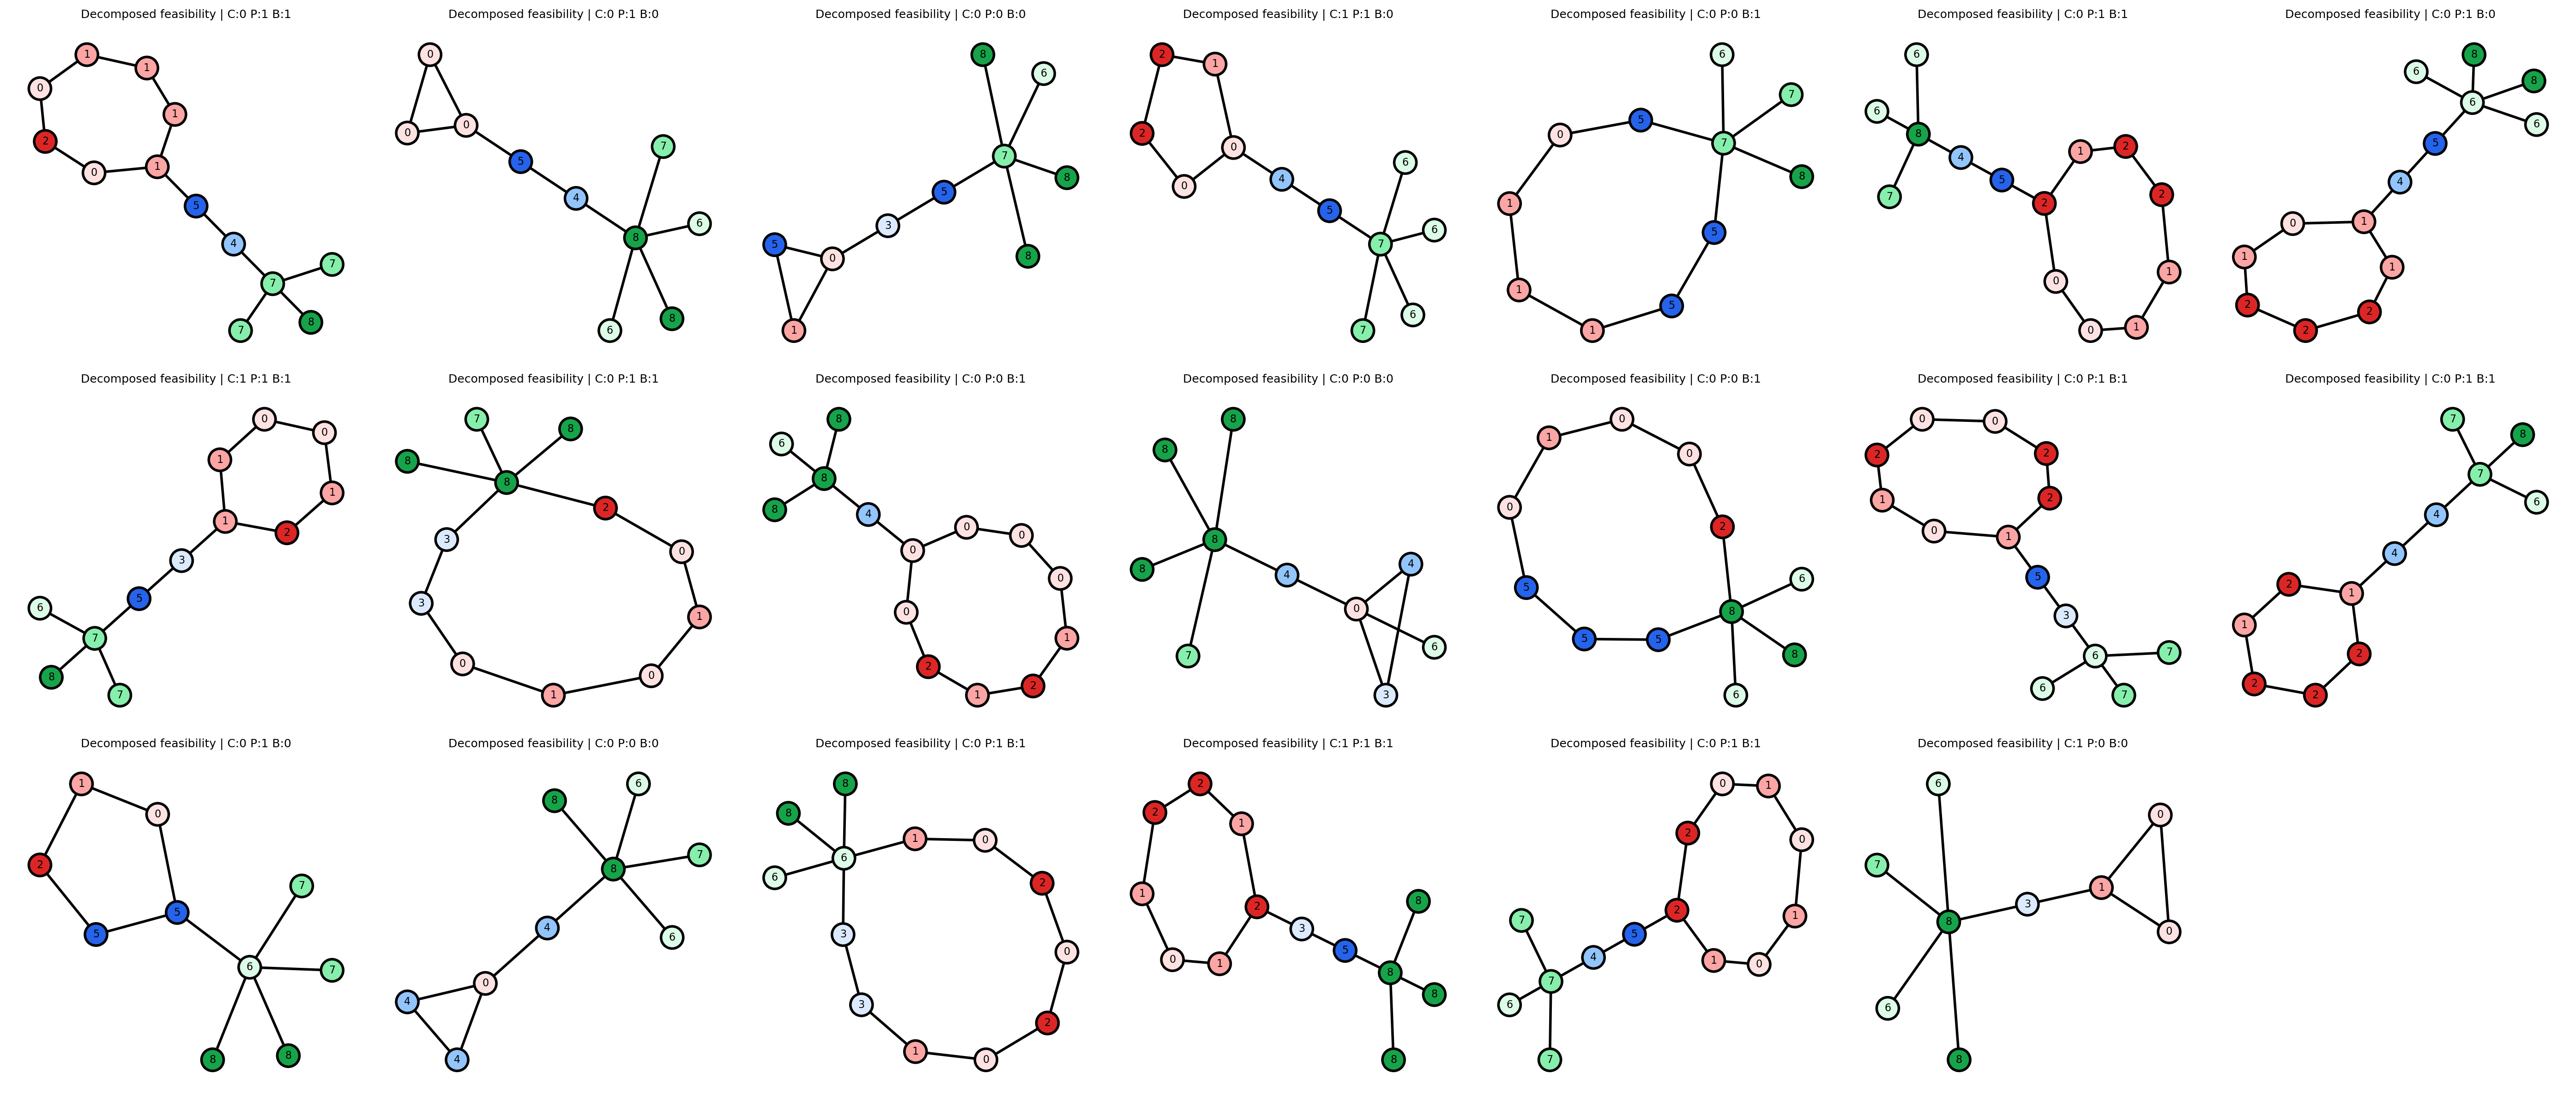

In [ ]:
part_feasibility = score_artificial_part_feasibility(
    artificial_part_feasibility_estimators,
    filtered_samples,
)
overall_feasible = part_feasibility.all(axis=1).to_numpy(dtype=bool)
part_title_labels = {'cycle': 'C', 'path': 'P', 'branching': 'B'}
sample_titles = [
    ' '.join(
        f'{part_title_labels.get(part, part[:1].upper())}:{int(is_feasible)}'
        for part, is_feasible in row.items()
    )
    for row in part_feasibility.to_dict('records')
]

print(f'Feasible generated graphs: {int(overall_feasible.sum())}/{len(filtered_samples)}')
display(part_feasibility.value_counts(sort=False).rename('count').reset_index())

display(artificial_true_count_histogram(part_feasibility))

_ = draw_graphs(
    filtered_samples,
    n=len(filtered_samples),
    titles=sample_titles,
    title='Decomposed feasibility',
    n_graphs_per_line=min(7, N_SAMPLES),
)


In [ ]:
EFFORT_COMPARISON_N_GRAPHS = 100
EFFORT_COMPARISON_MIN = 0
EFFORT_COMPARISON_MAX = 5

effort_histogram, effort_fraction_table = compare_artificial_feasibility_efforts(
    graph_generator,
    artificial_part_feasibility_estimators,
    n_graphs=EFFORT_COMPARISON_N_GRAPHS,
    effort_min=EFFORT_COMPARISON_MIN,
    effort_max=EFFORT_COMPARISON_MAX,
    feasibility_filter=FEASIBILITY_FILTER,
)

display(effort_fraction_table)
display(effort_histogram)
